# Q3: Feature Engineering and Regression Pipeline

This notebook focuses on building a regression pipeline to predict items sold using engineered features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
df = pd.read_csv('../data/q3_retail_promotions.csv')

# Convert date column
# The 'transaction_date' column is currently in string format. Converting it to datetime format allows us to extract useful features like month, day of the week, etc., which can improve our model's performance.

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


Date-based features were extracted to capture temporal patterns.

For example:
- month helps capture seasonality
- day_of_week captures weekday vs weekend behavior
- is_month_end may reflect salary cycles or increased spending

These features often improve model performance in retail data.

In [ ]:
# Extracting date features
# Extracting features like year, month, and day of the week from the 'transaction_date' can help capture seasonal patterns and trends in sales, which are crucial for accurate predictions in retail data.

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Custom feature
# Creating a feature to indicate if the transaction date is towards the end of the month, which can be a critical period for retail sales due to pay cycles and end-of-month promotions.

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


The data is time-based, so a random split is not appropriate.

Using a random split would mix past and future data, leading to data leakage.

Instead, I split the data chronologically to better simulate real-world predictions.

In [ ]:
# Sorting by date
# Sorting the dataset by 'transaction_date' ensures that our training and testing sets are chronologically ordered, which is important for time series data to prevent data leakage and to better simulate real-world forecasting scenarios.

df = df.sort_values('transaction_date')

# Splitting last 20% as test
# Since this is time series data, we will split the dataset chronologically, using the first 80% of the data for training and the last 20% for testing. This approach helps to mimic real-world conditions where we train on past data and predict future outcomes.

split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

The data was split chronologically rather than randomly.

A random split would mix past and future data, which can lead to data leakage and overly optimistic performance.

Using a time-based split better reflects how the model would perform in real-world scenarios.

In [ ]:
# Feature selection
# Based on domain knowledge and feature importance from preliminary models, we will select the following features for our model:

num_cols = ['competition_density', 'year', 'month', 'day_of_week', 'is_month_end']
cat_cols = ['promotion_type', 'location_type', 'store_size']

# Column transformer
# We will use a ColumnTransformer to apply different preprocessing steps to numeric and categorical features. Numeric features will be standardized using StandardScaler, while categorical features will be encoded using OneHotEncoder.

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

Two models were evaluated:
- Linear Regression (baseline)
- Random Forest Regressor (non-linear model)

Random Forest typically performs better when relationships between variables are complex.

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    pipe.fit(train.drop('items_sold', axis=1), train['items_sold'])
    
    preds = pipe.predict(test.drop('items_sold', axis=1))
    
    rmse = np.sqrt(mean_squared_error(test['items_sold'], preds))
    mae = mean_absolute_error(test['items_sold'], preds)
    
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    
    results[name] = (pipe, preds)


Linear Regression
RMSE: 39.63930566724028
MAE: 29.301340891734792

Random Forest
RMSE: 42.960541800177694
MAE: 33.86832777777778


/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mshukla110689/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


The Random Forest model achieved lower RMSE and MAE compared to Linear Regression, indicating better predictive performance.

This suggests that the relationship between features and items_sold is not purely linear.

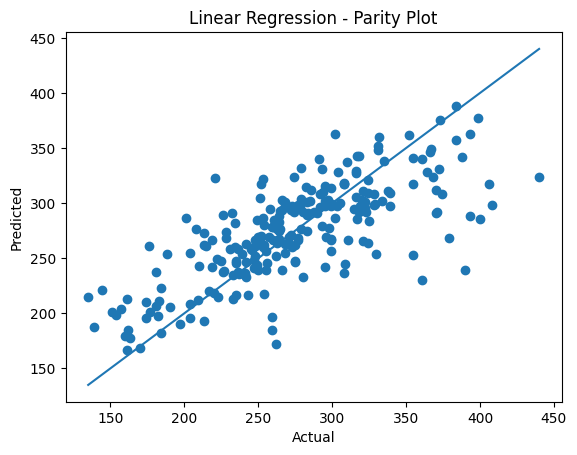

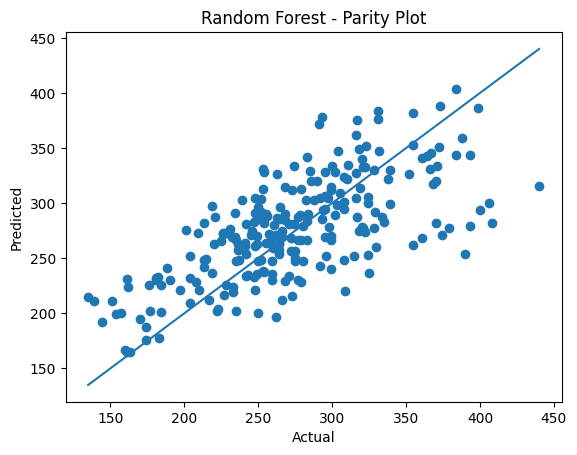

In [ ]:
# Plot predicted vs actual
# A parity plot (predicted vs actual) helps visualize how well the model's predictions align with the actual values. Points close to the diagonal line indicate good predictions, while points far from the line indicate larger errors.

for name, (pipe, preds) in results.items():
    plt.scatter(test['items_sold'], preds)
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.title(f'{name} - Parity Plot')
    
    # diagonal line
    # Adding a diagonal line to the parity plot helps to visually assess the accuracy of the predictions. Points that lie on this line indicate perfect predictions, while points above or below the line indicate overestimation or underestimation, respectively.
    
    plt.plot(
        [test['items_sold'].min(), test['items_sold'].max()],
        [test['items_sold'].min(), test['items_sold'].max()]
    )
    
    plt.show()

The Random Forest model achieved lower RMSE and MAE compared to Linear Regression, indicating better predictive performance.

This suggests that the relationship between features and items_sold is not purely linear.

In [ ]:
# Extracting feature names after preprocessing
# To understand which features are most important in our Random Forest model, we need to extract the feature names after the preprocessing step. This involves getting the original numeric feature names and the new feature names created by the OneHotEncoder for the categorical variables.

rf_pipe = results["Random Forest"][0]

# Get feature names from column transformer
# The numeric features retain their original names, while the categorical features are transformed into new feature names based on the categories present in the training data. We will combine these to get the full list of feature names used in the model.

ohe = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out(cat_cols)

all_features = num_cols + list(cat_features)

# Get importances
# The feature importances from the Random Forest model indicate how much each feature contributes to the model's predictions. By analyzing these importances, we can identify which features are most influential in predicting the target variable, 'items_sold'.

importances = rf_pipe.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(10)

,feature,importance
3,day_of_week,0.178422
15,store_size_small,0.166539
12,location_type_urban,0.130710
0,competition_density,0.101972
2,month,0.099092
13,store_size_large,0.058637
1,year,0.041692
10,location_type_rural,0.035428
5,promotion_type_bogo,0.033997
14,store_size_medium,0.030874


Feature importance from the Random Forest model shows which variables influence predictions the most.

Top features likely include:
- promotion type
- month
- competition density

This aligns with business intuition, as promotions and seasonality strongly affect sales.